# 1 - create a BaggingClassifier model from Scikit-learn combining KNeighborsClassifier, OneVsRestClassifier and DecisionTreeClassifier

In [19]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
# from sklearn.model_selection import train_split
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.ensemble import BaggingClassifier

train_data=pd.read_csv("fashion-mnist_train.csv")
test_data=pd.read_csv("fashion-mnist_test.csv")
y_train=train_data["label"]
x_train=train_data.drop("label", axis=1)
y_test=test_data["label"]
x_test=test_data.drop("label", axis=1)
# x_train, y_train=train_split
# x_train, y_train=train_data
# print(x)
bagging_clf1 = BaggingClassifier(
    estimator=OneVsRestClassifier(DecisionTreeClassifier(criterion="gini")),
    n_estimators=10,
    random_state=42,
    bootstrap=True,
    max_samples=0.01
)
bagging_clf1.fit(x_train, y_train)   

y_pred1 = bagging_clf1.predict(x_test)
# print(y_pred1)
accuracy = accuracy_score(y_test, y_pred1)
print(f"BaggingClassifier Accuracy: {accuracy}")

bagging_clf2=BaggingClassifier(
    estimator=OneVsRestClassifier(KNeighborsClassifier()),
    n_estimators=10,
    random_state=42,
    bootstrap=True,
    max_samples=0.01
)

bagging_clf=bagging_clf2.fit(x_train,y_train)
y_pred=bagging_clf2.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"BaggingClassifier Accuracy: {accuracy}")
# print(y_pred)


BaggingClassifier Accuracy: 0.7799
BaggingClassifier Accuracy: 0.7833


In [21]:
print(f"better predictive performance is : bagging_clf2 with accuracy_score= {accuracy}")

better predictive performance is : bagging_clf2 with accuracy_score= 0.7833


# 2 - display the performance indicators of your model : precision score, recall score and confusion matrix

Performance indicators
Precision score:  0.7833
Recall score:  0.7833

Confusion Matrix:
[[856   1  29  43   7   1  49   1  13   0]
 [ 12 936  16  23   6   0   7   0   0   0]
 [ 18   1 638   3 150   0 183   0   7   0]
 [ 58  21   8 846  41   0  25   0   1   0]
 [  5   5  83  32 732   0 139   0   4   0]
 [  2   0   1   0   0 671  21 204   7  94]
 [282   2 121  22  94   0 467   0  12   0]
 [  0   0   0   0   0  17   0 897   0  86]
 [  4   1  25  21  13   3  43  26 862   2]
 [  1   0   0   0   0   5   4  62   0 928]]


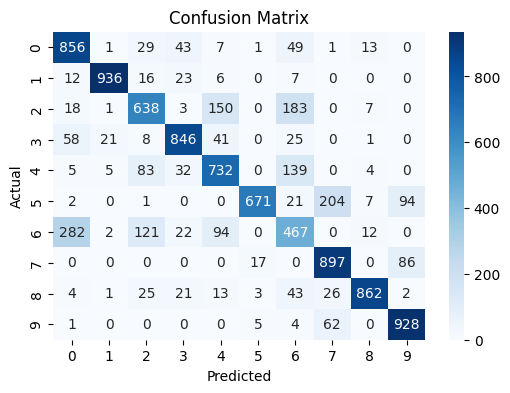

In [23]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

precision=precision_score(y_test, y_pred,average="micro")
recall=recall_score(y_test,y_pred,average="micro")
print("Performance indicators")
print("Precision score: ",precision)
print("Recall score: ",recall)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            # xticklabels=['No Label', ' Label'],
            # yticklabels=['No Label', 'Label'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Exercise 2

[0 1 2 ... 8 8 2]
Performance indicators
Precision score:  0.8846
Recall score:  0.8846

Confusion Matrix:
[[859   0  13  30   1   1  84   0  12   0]
 [  2 973   6  14   1   1   3   0   0   0]
 [  7   1 809  12 107   0  54   0  10   0]
 [ 16   8   7 928  23   0  18   0   0   0]
 [  1   0  55  28 868   0  45   0   3   0]
 [  0   0   0   0   0 947   0  35   6  12]
 [177   1  95  26  79   0 605   0  17   0]
 [  0   0   0   0   0  15   0 932   0  53]
 [  2   1   4   0   2   2  11   2 976   0]
 [  0   0   0   0   0   7   1  40   3 949]]


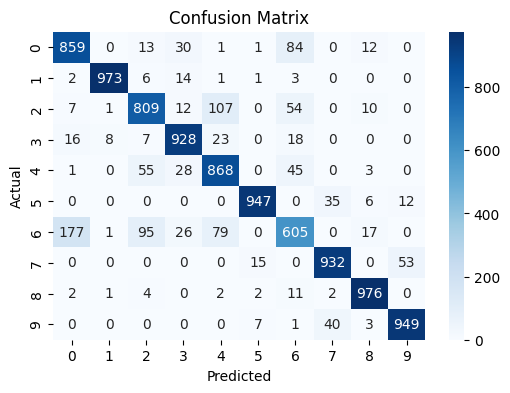

In [25]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(criterion="gini")
model=model.fit(x_train, y_train)
y_pred2=model.predict(x_test)
print(y_pred2)

precision=precision_score(y_test, y_pred2,average="micro")
recall=recall_score(y_test,y_pred2,average="micro")
print("Performance indicators")
print("Precision score: ",precision)
print("Recall score: ",recall)
cm = confusion_matrix(y_test, y_pred2)
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            # xticklabels=['No Label', ' Label'],
            # yticklabels=['No Label', 'Label'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()